# Poisson 2D

This notebook implements a flowPINN for the Poisson2D model

## Preliminaries

Whether to run computations on GPU or CPU

In [1]:
import os

USE_GPU: bool = True

if not USE_GPU:
    os.environ['JAX_PLATFORM_NAME'] = 'cpu'
else:
    os.environ["CUDA_VISIBLE_DEVICES"] = str(0)
    os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

Package imports

In [2]:
import jax.numpy as jnp
import jax.random as jr
from jax.scipy.stats import multivariate_normal, norm

import optax
from jax import config, devices

import pickle
from functools import partial
from typing import Callable

import os

# ensure that we can access flowpinns
import sys
sys.path.append('../../')

from flowpinns.training_utils import init_learner
from flowpinns.data_utils import DataLoader
from flowpinns import inverse_autoregressive_flow
from flowpinns import parameterised_PINN
from flowpinns import objective_fns
from flowpinns.flow_setup import initialise_flow 
from flowpinns import utils
from flowpinns.utils import *

Uncomment below for debugging

In [3]:
# config.update("jax_debug_nans", True)

Check what devices are available

In [4]:
devices()

[CudaDevice(id=0)]

### Specify the experiment settings 

In [5]:
# -----------------------------------------------------------------------------
# Random seed
# -----------------------------------------------------------------------------

# Base PRNG key used for the experiment
rng_key = jr.key(2001)


# -----------------------------------------------------------------------------
# Observation configuration
# -----------------------------------------------------------------------------

# Number of noisy solution-space observations
Nu: int = 25

# Std. deviation of the noise applied when generating solution-space observations,
# as a fraction of the std. deviation of the true underlying function u
# we can control this value because this is a synthetic problem
NOISE_FRAC: float = 0.1
assert 0. <= NOISE_FRAC <= 1.

# -----------------------------------------------------------------------------
# Experiment configuration container
# -----------------------------------------------------------------------------

# Dictionary storing all experiment settings
SETTINGS = {}


# -----------------------------------------------------------------------------
# PDE parameter configuration
# -----------------------------------------------------------------------------

# Initial estimate of the PDE parameter vector theta.
# Used only for initialising the flow and PINN models.
SETTINGS['theta_init']: Array = jnp.array([2., 2.])

# Dimensionality of the parameter vector theta
SETTINGS['D_theta'] = SETTINGS['theta_init'].shape[0]

# Nonlinear transforms used to enforce parameter constraints
# (e.g. positivity of theta and noise parameters)
SETTINGS['theta_transform']: Callable = utils.softplus
SETTINGS['noise_transform']: Callable = utils.softplus


# -----------------------------------------------------------------------------
# Data storage
# -----------------------------------------------------------------------------

# We provide one regeneration of the underlying data 
data_save_dir: str = f'../data/poisson2D'
assert os.path.isdir(data_save_dir)


# -----------------------------------------------------------------------------
# Prior distribution on SoftPlus(theta)
# -----------------------------------------------------------------------------

# Mean and standard deviation of the Gaussian prior on SoftPlus(theta)
SETTINGS['prior_mean']: float = 4.
SETTINGS['prior_std']: float = 2.


# -----------------------------------------------------------------------------
# Normalising flow configuration
# -----------------------------------------------------------------------------

# Architecture of the normalising flow
SETTINGS['flow_depth']: int = 1
SETTINGS['flow_width']: int = 128
SETTINGS['n_flows']: int = 4        # Number of flow layers (K in Eq. 3)


# -----------------------------------------------------------------------------
# PINN architecture
# -----------------------------------------------------------------------------

# Width and depth of the parameterised PINN
SETTINGS['pinn_width']: int = 128
SETTINGS['pinn_depth']: int = 4


# -----------------------------------------------------------------------------
# ELBO estimation
# -----------------------------------------------------------------------------

# Number of theta samples used when approximating the ELBO
SETTINGS['n_theta_samples_elbo']: int = 100


# -----------------------------------------------------------------------------
# Stage One training configuration
# -----------------------------------------------------------------------------

# Size of the data subsample used during Stage One training
# (denoted M in Eq. 13 of the paper). Must not exceed Nu.
# Choose the lowest value that yields a stable estimate
# of yf_noise_std
M = 2
SETTINGS['stage_one_batch_size']: int = M

assert SETTINGS['stage_one_batch_size'] <= Nu


# -----------------------------------------------------------------------------
# Stage Two training configuration
# -----------------------------------------------------------------------------

# Number of PDE collocation points used per optimisation step
SETTINGS['stage_two_batch_size']: int = 128

# Number of theta samples used for PINN loss function in Stage Two
SETTINGS['n_theta_samples_s2']: int = 50


# -----------------------------------------------------------------------------
# Training schedule
# -----------------------------------------------------------------------------

# Number of optimisation steps for each stage of training
SETTINGS['n_train_s1']: int = 100000
SETTINGS['n_train_pinn_s2']: int = 30000
SETTINGS['n_train_flow_s3']: int = 20000

# Short training schedule used for debugging
# SETTINGS['n_train_s1']: int = 500
# SETTINGS['n_train_pinn_s2']: int = 500
# SETTINGS['n_train_flow_s3']: int = 1000 


# -----------------------------------------------------------------------------
# Optimisation settings
# -----------------------------------------------------------------------------

# Initial learning rate used across training stages
SETTINGS['lr_init']: float = 1e-4

### Data processing

Create directory to save results and settings

In [6]:
total_n_train = SETTINGS['n_train_s1'] + SETTINGS['n_train_pinn_s2'] + SETTINGS['n_train_flow_s3']
results_save_dir_base = f"results/poisson2D/flowPINN/Nu_{Nu}_Nbatch_{SETTINGS['stage_one_batch_size']}_K_{SETTINGS['n_flows']}_NOISE_FRAC_{NOISE_FRAC}_n_train_{total_n_train}"

save_dirs = SaveDirs.create(results_save_dir_base)

save_dict_to_txt(SETTINGS, os.path.join(save_dirs.base, f"SETTINGS.txt"))
save_dirs.base

'results/poisson2D/flowPINN/Nu_25_Nbatch_2_K_4_NOISE_FRAC_0.1_n_train_150000'

Load data. The collocation data are stored in ``(X_f, y_f)``, and the noisy solution space data are stored in ``(X_u, y_u)``

In [7]:
train_data = load_train_data(data_save_dir, Nu, NOISE_FRAC)
train_data.Xf.shape, train_data.yf.shape, train_data.Xu.shape, train_data.yu.shape

((1024, 2), (1024,), (25, 2), (25,))

Place train_data in a DataLoader for batch training

In [8]:
train_data_loader = DataLoader(train_data, SETTINGS['stage_one_batch_size'], SETTINGS['stage_two_batch_size'])

In [9]:
rng_use_elbo, rng_use_pinn, rng_key = jr.split(rng_key, 3)
elbo_validation_batch = train_data_loader.get_fixed_batch(rng_use_elbo, Nbatch_f=train_data_loader.Nu*3)
pinn_validation_batch = train_data_loader.get_colloc_batch(rng_use_pinn, Nbatch_f=SETTINGS['stage_two_batch_size'])

Keep track of the dimensions of the data

In [10]:
D_in = train_data.Xu.shape[-1]
D_out = 1

Useful for intialising the PINN

In [11]:
x_init = train_data.Xu[0]

### Initialise Normalising Flow

In [12]:
key_use, rng_key = jr.split(rng_key, 2)
flow_sampler, flow_params_init = initialise_flow(key_use, SETTINGS)

Plot samples from the prior distribution over $\theta$

In [13]:
key_use, rng_key = jr.split(rng_key, 2)
n_prior_samples = 1000
prior_theta_samples = SETTINGS['theta_transform'](flow_sampler.prior_sample(key_use, n_prior_samples))

In [14]:
SETTINGS['prior_mean'], prior_theta_samples.mean(0), SETTINGS['prior_std'], prior_theta_samples.std(0)

(4.0,
 Array([4.0173216, 4.026964 ], dtype=float32),
 2.0,
 Array([1.8456087, 1.8675228], dtype=float32))

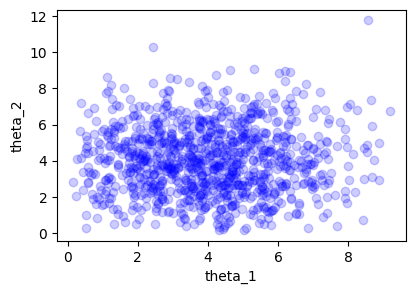

In [15]:
plot_theta_samples(prior_theta_samples, save_name= os.path.join(save_dirs.plots, f'prior_theta_samples_plot.pdf'))

Plot samples from the flow distribution over $\theta$ with randomly initialised flow parameters

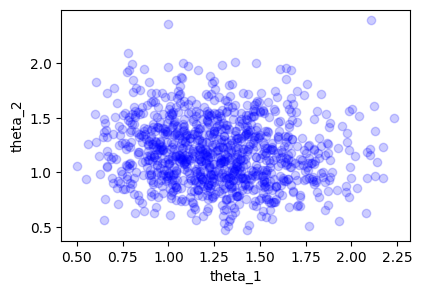

In [16]:
use_key, rng_key = jr.split(rng_key, 2)
theta_z, log_det_jacobian = flow_sampler.posterior_sample(key_use, n_prior_samples, flow_params_init)
flow_theta_samples_init = SETTINGS['theta_transform'](theta_z)
plot_theta_samples(flow_theta_samples_init, save_name= os.path.join(save_dirs.plots, f'flow_samples_at_initialisation.pdf'))

### Initialise Parameterised PINN 

First define an approximate distance function and mean function which together ensure that the Dirichlet condition is exactly enforced by the parmameterised PINN. This is discussed in Appendix E.7.1 of the paper.

In [17]:
def _boundary_factor(x: Array) -> FloatArray:
    """
    1D boundary vanishing factor.

    Returns zero at x = 0 and x = 1, and positive values inside (0,1).
    """
    return 4. * x * (1. - x)


def adf(loc: Array) -> FloatArray:
    """
    Approximate distance function (ADF) for the unit cube [0,1]^3
    """
    x, y = loc
    return _boundary_factor(x) * _boundary_factor(y) 


def mean_fn(loc: Array) -> FloatArray:
    """
    Mean function which exactly satisfies the Dirichlet condition
    """
    x, y = loc
    return 0.5 * x * jnp.sin(2.*jnp.pi*y) 

We use a simplified [parameterised PINN]((https://arxiv.org/abs/2408.09446v1)) in which the PDE parameters are concatenated directly with the spatial inputs. We also experimented with the two-branch architecture proposed by the authors, but observed little difference in results

In [18]:
pinn_model = parameterised_PINN.SimpleP2INN([SETTINGS['pinn_width']]*SETTINGS['pinn_depth'] + [D_out], adf=adf, mean_fn=mean_fn)

use_key, rng_key = jr.split(rng_key, 2)
pinn_params_init = pinn_model.init(use_key, x_init, SETTINGS['theta_init'])

Define a prediction function for the PDE solution $u$ which makes a prediction for a single spatial location / PDE parameter pair

In [19]:
upred_fn = pinn_model.apply
upred_fn(pinn_params_init, x_init, SETTINGS['theta_init'])

Array(-0.01240452, dtype=float32)

Vmap to allow for predictions are multiple input locations with common PDE parameter value $\theta$

In [20]:
upred_vmap = jax.vmap(upred_fn, in_axes=[None,0, None])
upred_vmap(pinn_params_init, train_data.Xu, SETTINGS['theta_init']).shape, train_data.yu.shape

((25,), (25,))

### Specify the differential operator

This experiment involves the anisotropic Poisson equation over two spatial dimensions,

$$\mathcal{F}_{\boldsymbol{\theta}}[u]
=
-\left(
\theta_1 \frac{\partial^2 u}{\partial x^2}
+
\theta_2 \frac{\partial^2 u}{\partial y^2}
\right)
= f.
$$

Here $u(\boldsymbol{x})$ denotes the solution field and $\boldsymbol{\theta} = (\theta_1,\theta_2)$ are the PDE coefficients controlling the contribution of each second derivative.

The function below constructs the differential operator $\mathcal{F}_{\boldsymbol{\theta}}$ for a given neural network representation of  $u$.  
Applying the operator to the network yields the corresponding right-hand side (RHS) function $f$.

In [21]:
def apply_PDE_pinn(fn: Callable, theta_transform: Callable) -> Callable:
    """
    Construct a function that applies the Poisson PDE operator to a PINN.
    """

    # Hessian of network output wrt spatial coordinates
    hessian_fn = jax.hessian(fn, argnums=1)

    def pde_operator(params: Dict, loc: Array, theta_z: Array) -> FloatArray:
        """
        Evaluate the Poisson PDE at single spatial location loc, given
        (raw scale) PDE parameter vector theta
        """

        # Extract second derivatives on the diagonal of the Hessian
        laplacian_terms = jnp.diag(hessian_fn(params, loc, theta_z))

        # Transform PDE parameters to physical scale
        theta = theta_transform(theta_z)

        # Weighted Laplacian
        laplacian = jnp.sum(laplacian_terms * theta)

        return -laplacian

    return pde_operator

Define a prediction function for the PDE forcing $f$ which makes a prediction for a single spatial location / PDE parameter pair

In [22]:
fpred_fn = apply_PDE_pinn(upred_fn, SETTINGS['theta_transform'])
fpred_fn(pinn_params_init, x_init, SETTINGS['theta_init'])

Array(0.64095855, dtype=float32)

Vmap to allow for predictions are multiple input locations with common PDE parameter value $\boldsymbol{\theta}$

In [23]:
fpred_vmap = jax.vmap(fpred_fn, in_axes=[None,0, None])
fpred_vmap(pinn_params_init, train_data.Xf, SETTINGS['theta_init']).shape, train_data.yf.shape

((1024,), (1024,))

Vmap again over different values of $\boldsymbol{\theta}$

In [24]:
fpred_vmap2 = jax.vmap(fpred_vmap, in_axes=[None,None, 0])

fpred_vmap2(pinn_params_init, train_data.Xf, jnp.tile(SETTINGS['theta_init'].reshape(-1,1),2).T).shape, train_data.yf.shape

((2, 1024), (1024,))

## FlowPINN Model Training

We perform training in three sequential stages, following the description in Section 4.1 of the paper:

- **Stage One:** Train the `flow`, `pinn`, and `likelihood` parameters jointly using a **subsampled ELBO**. At each training step, only `stage_one_batch_size` (< `Nu`) solution-space observations are used.

- **Stage Two:** Train the `pinn` parameters while keeping the `flow` and `likelihood` parameters fixed from Stage One.

- **Stage Three:** Train the `flow` and `likelihood` parameters on the ELBO using **all `Nu` observations**, with the `pinn` parameters held fixed from Stage Two.

This staged training strategy helps to prevent overfitting of the flow posterior

### Stage One Training

Initialise the flow, PINN and likelihood parameters

In [25]:
params_init = {}
params_init['flow_params'] = flow_params_init 
params_init['pinn_params'] = pinn_params_init

# initialise noise std to 5% of the level seen in the training data
yu_noise_init = train_data_loader.yu.std()*.05
yf_noise_init = train_data_loader.yf.std()*.05
params_init['likelihood_params'] = SETTINGS['noise_transform'](jnp.array([yu_noise_init, yf_noise_init]), True)

Define the objective function

In [26]:
s1_elbo_obj_fn, s1_posterior =  objective_fns.get_elbo_objective_fn(SETTINGS, flow_sampler, upred_vmap, fpred_vmap)

Initialise the learner

In [27]:
s1_rng, rng_key = jr.split(rng_key, 2)

s1_train_batch_loader = train_data_loader.get_batch

stage1_learner = init_learner(
    stage = "stage1",
    params = params_init,
    loss_fn = s1_elbo_obj_fn,
    learning_rate = SETTINGS['lr_init'],
    rng = s1_rng,
    noise_transform = SETTINGS['noise_transform'],
    train_batch_loader = s1_train_batch_loader,
    validation_batch = elbo_validation_batch
)

Uncomment below to check that everything runs correctly

In [28]:
# use_key1, use_key2, use_key3 = jr.split(jr.key(0), 3)
# check_batch = s1_train_batch_loader(use_key2)

# _ = s1_posterior(SETTINGS['theta_init'], params_init, check_batch)
# _ = s1_elbo_obj_fn(params_init, use_key1, check_batch)
# _ = stage1_learner.train_step_fn(stage1_learner.opt_state, params_init, use_key2)

Uncomment below to update the learning rate of the Adam optimiser

In [29]:
# stage1_learner.opt_state.hyperparams['learning_rate'] /=  2.

Train the ``flow``, ``pinn`` and ``yu_noise_std`` likelihood parameters jointly

In [30]:
stage1_learner.train(1) # run one train step for jit compilation

(1), Obj/Valid: 15175.42/169046.08, lr: 1.0e-04, sample mean/std: [1.3325769 1.181456 ]/[0.3416217  0.30890155], noise_stds: 1.235e-02/3.102e-01


In [31]:
stage1_learner.train(SETTINGS['n_train_s1'])

(2), Obj/Valid: 9755.42/150707.14, lr: 1.0e-04, sample mean/std: [1.287859  1.2625054]/[0.32568562 0.30059236], noise_stds: 1.235e-02/3.102e-01
(10002), Obj/Valid: 49.81/536.78, lr: 1.0e-04, sample mean/std: [1.3553323  0.73013824]/[0.25695705 0.09593743], noise_stds: 1.670e-02/4.305e-01
(20002), Obj/Valid: 13.12/55.38, lr: 1.0e-04, sample mean/std: [1.2712985 0.8174712]/[0.188054  0.1189235], noise_stds: 2.507e-02/6.062e-01
(30002), Obj/Valid: 8.68/64.56, lr: 1.0e-04, sample mean/std: [1.219662   0.83159834]/[0.15749538 0.1336924 ], noise_stds: 3.004e-02/7.862e-01
(40002), Obj/Valid: 12.44/61.10, lr: 1.0e-04, sample mean/std: [1.2598237 0.8790919]/[0.1931243  0.18776555], noise_stds: 3.080e-02/9.109e-01
(50002), Obj/Valid: 8.15/61.29, lr: 1.0e-04, sample mean/std: [1.193582  0.9817636]/[0.21949258 0.2125266 ], noise_stds: 3.047e-02/1.015e+00
(60002), Obj/Valid: 7.96/69.37, lr: 1.0e-04, sample mean/std: [1.1730275 0.969555 ]/[0.24996476 0.23267831], noise_stds: 3.010e-02/1.080e+00
(700

Save the trained parameters

In [32]:
stage1_trained_params = stage1_learner.params.copy()

In [33]:
with open(os.path.join(save_dirs.nn_params, f's1_params.pkl'), 'wb') as fp:
    pickle.dump(stage1_trained_params, fp)

In [34]:
del stage1_learner

Plot and save the Stage One Posterior samples of $\theta$

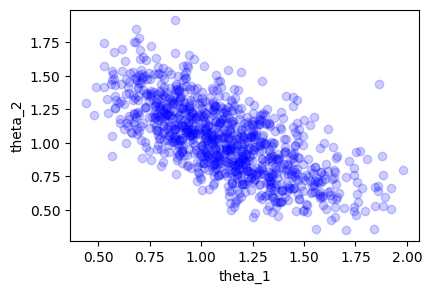

In [35]:
use_key, rng_key = jr.split(rng_key, 2)

s1_theta_z, log_det_jacobian = flow_sampler.posterior_sample(key_use, n_prior_samples, stage1_trained_params['flow_params'])
s1_theta_samples = SETTINGS['theta_transform'](s1_theta_z)

plot_theta_samples(s1_theta_samples, save_name= os.path.join(save_dirs.plots, f's1_theta_samples_plot.pdf'))

### Stage Two Training

Define the objective function

In [36]:
s2_obj_fn = partial(objective_fns.pinn_obj_fn, pred_fn_vmap2=fpred_vmap2)

Initialise the learner

In [37]:
s2_rng, rng_key = jr.split(rng_key, 2)

s2_train_batch_loader = train_data_loader.get_colloc_batch

s2_flow_sampler = lambda key: flow_sampler.posterior_sample(key, SETTINGS['n_theta_samples_s2'], stage1_trained_params['flow_params'])[0]

stage2_learner = init_learner(
    stage = "stage2",
    params = stage1_trained_params['pinn_params'],
    loss_fn = s2_obj_fn,
    noise_transform = SETTINGS['noise_transform'],
    learning_rate = SETTINGS['lr_init'],
    rng = s2_rng,
    train_batch_loader = s2_train_batch_loader,
    validation_batch = pinn_validation_batch,
    flow_sampler = s2_flow_sampler,
)

Uncomment below to check that everything runs correctly

In [38]:
# use_key1, use_key2, use_key3 = jr.split(jr.key(0), 3)
# Xf_batch, yf_batch = s2_train_batch_loader(use_key2)

# _ = s2_obj_fn(stage2_learner.params, s1_theta_samples[:10], Xf_batch, yf_batch)
# _ = stage2_learner.train_step_fn(stage2_learner.opt_state, stage2_learner.params, use_key2)

Uncomment below to update the learning rate of the Adam optimiser

In [39]:
# stage2_learner.opt_state.hyperparams['learning_rate'] /=  2.

Train the ``pinn`` parameters with the ``flow`` and ``yu_noise_std`` likelihood parameters held fixed

In [40]:
stage2_learner.train(1) # run one train step for jit compilation

(1), Obj/Valid: 7.827e-01/6.917e-01, lr: 1.0e-04


In [41]:
stage2_learner.train(SETTINGS['n_train_pinn_s2'])

(2), Obj/Valid: 6.153e-01/5.530e-01, lr: 1.0e-04
(3002), Obj/Valid: 1.600e-02/3.081e-02, lr: 1.0e-04
(6002), Obj/Valid: 2.076e-02/1.620e-02, lr: 1.0e-04
(9002), Obj/Valid: 7.349e-03/8.596e-03, lr: 1.0e-04
(12002), Obj/Valid: 5.200e-03/6.763e-03, lr: 1.0e-04
(15002), Obj/Valid: 1.284e-02/7.213e-03, lr: 1.0e-04
(18002), Obj/Valid: 7.335e-03/5.180e-03, lr: 1.0e-04
(21002), Obj/Valid: 3.361e-03/3.002e-03, lr: 1.0e-04
(24002), Obj/Valid: 2.356e-03/4.025e-03, lr: 1.0e-04
(27002), Obj/Valid: 2.192e-03/1.862e-03, lr: 1.0e-04
(30001), Obj/Valid: 1.666e-03/1.862e-03, lr: 1.0e-04


Save the trained parameters

In [42]:
stage2_trained_pinn_params = stage2_learner.params.copy()

Use Stage 2 loss value to give a final estimate of  ``yf_noise_std``, which is fixed in Stage Three training

In [43]:
fixed_yf_noise_std = stage2_learner.loss**.5

In [44]:
with open(os.path.join(save_dirs.nn_params, f's2_pinn_params.pkl'), 'wb') as fp:
    pickle.dump(stage2_trained_pinn_params, fp)

In [45]:
del stage2_learner

### Stage Three Training

Define the objective function

In [46]:
s3_elbo_obj_fn, s3_posterior =  objective_fns.get_elbo_objective_fn(SETTINGS, flow_sampler, upred_vmap, fpred_vmap, stage2_trained_pinn_params, fixed_yf_noise_std)

Initialise the trainable parameters

In [47]:
s3_yu_noise_std_init = SETTINGS['noise_transform'](stage1_trained_params['likelihood_params'][0])
s3_yu_noise_std_init, fixed_yf_noise_std 

(Array(0.03008482, dtype=float32), Array(0.04082203, dtype=float32))

In [48]:
s3_params_init = {}
s3_params_init['flow_params']       = stage1_trained_params['flow_params']
s3_params_init['likelihood_params'] = SETTINGS['noise_transform'](jnp.array([s3_yu_noise_std_init, fixed_yf_noise_std]), True)

Initialise the learner

In [49]:
s3_rng, valid_rng, rng_key = jr.split(rng_key, 3)

s3_train_batch_loader = lambda rng: train_data_loader.get_fixed_batch(rng, Nbatch_f=train_data_loader.Nu)
valid_batch = train_data_loader.get_fixed_batch(valid_rng, Nbatch_f=train_data_loader.Nu*3)

stage3_learner = init_learner(
    stage = "stage3",
    params = s3_params_init,
    loss_fn = s3_elbo_obj_fn,
    learning_rate = SETTINGS['lr_init'],
    rng = s3_rng,
    noise_transform = SETTINGS['noise_transform'],
    train_batch_loader = s3_train_batch_loader,
    validation_batch = elbo_validation_batch,
)

Uncomment below to check that everything runs correctly

In [50]:
# use_key1, use_key2, use_key3 = jr.split(jr.key(0), 3)
# check_batch = s3_train_batch_loader(use_key2)

# _ = s3_posterior(SETTINGS['theta_init'], stage3_learner.params, check_batch)
# _ = s3_elbo_obj_fn(stage3_learner.params, use_key1, check_batch)
# _ = stage3_learner.train_step_fn(stage3_learner.opt_state, stage3_learner.params, use_key2)

Uncomment below to update the learning rate of the Adam optimiser

In [51]:
# stage3_learner.opt_state.hyperparams['learning_rate'] /=  2.

Train the ``flow`` and ``yu_noise_std`` likelihood parameter, with the ``pinn`` parameters held fixed

In [52]:
stage3_learner.train(1) # run one train step for jit compilation

(1), Obj/Valid: -70.10/-148.82, lr: 1.0e-04, sample mean/std: [1.1476943 1.0305846]/[0.31359422 0.31137347], noise_stds: 3.009e-02/4.082e-02


In [53]:
stage3_learner.train(SETTINGS['n_train_flow_s3'])

(2), Obj/Valid: -78.37/-148.88, lr: 1.0e-04, sample mean/std: [1.139314  1.0132763]/[0.27600625 0.2639686 ], noise_stds: 3.009e-02/4.082e-02
(2002), Obj/Valid: -90.49/-178.86, lr: 1.0e-04, sample mean/std: [1.035705  1.0311978]/[0.19601078 0.19418992], noise_stds: 3.197e-02/4.082e-02
(4002), Obj/Valid: -90.42/-183.67, lr: 1.0e-04, sample mean/std: [1.0064198 1.0475641]/[0.15516727 0.13407603], noise_stds: 2.835e-02/4.082e-02
(6002), Obj/Valid: -94.27/-185.70, lr: 1.0e-04, sample mean/std: [1.024575  1.0336614]/[0.1250421 0.110094 ], noise_stds: 2.554e-02/4.082e-02
(8002), Obj/Valid: -97.31/-186.42, lr: 1.0e-04, sample mean/std: [1.0337183 1.0245599]/[0.10386906 0.09253106], noise_stds: 2.463e-02/4.082e-02
(10002), Obj/Valid: -95.05/-186.89, lr: 1.0e-04, sample mean/std: [1.0461009 1.0157188]/[0.09864899 0.09343757], noise_stds: 2.432e-02/4.082e-02
(12002), Obj/Valid: -93.15/-187.02, lr: 1.0e-04, sample mean/std: [1.04203   1.0073187]/[0.09393056 0.08514206], noise_stds: 2.418e-02/4.082

Save the trained parameters

In [54]:
stage3_trained_params = stage3_learner.params.copy()

In [55]:
with open(os.path.join(save_dirs.nn_params, f's3_params.pkl'), 'wb') as fp:
    pickle.dump(stage3_trained_params, fp)

In [56]:
del stage3_learner

## Results evaluation

Load ground truth data

In [57]:
theta_true = jnp.array([1., 1.])

test_data = load_test_data(data_save_dir)

test_data.Xs.shape, test_data.us.shape

((1156, 2), (1156,))

Uncomment the below to load pre-trained flow / PINN parameter values

In [58]:
# with open(os.path.join(save_dirs.nn_params, f's2_pinn_params.pkl'), 'rb') as f:
#     trained_pinn_params = pickle.load(f)

# with open(os.path.join(save_dirs.nn_params, f's3_params.pkl'), 'rb') as f:
#     trained_flow_params = pickle.load(f)['flow_params']

In [59]:
trained_pinn_params = stage2_trained_pinn_params
trained_flow_params = stage3_trained_params['flow_params']

In [60]:
trained_pinn = jax.jit(lambda Xs, theta_z: upred_vmap(trained_pinn_params, Xs, theta_z))
trained_flow = jax.jit(lambda key: flow_sampler.posterior_sample(key, n_theta_samples, trained_flow_params)[0])

n_theta_samples: int = 1000
n_us_samples   : int = 100

Sample from trained posterior

In [61]:
use_key, rng_key = jr.split(rng_key, 2)

theta_z_samples = trained_flow(use_key)

theta_samples = SETTINGS['theta_transform'](theta_z_samples)

print(f"theta_samples_mean: {theta_samples.mean(axis=0)}")
print(f"theta_samples_std : {theta_samples.std(axis=0)}")

theta_samples_mean: [1.0505928 1.0057961]
theta_samples_std : [0.07632253 0.06918494]


In [62]:
us_samples = jax.vmap(trained_pinn, in_axes=[None, 0])(test_data.Xs, theta_samples[:n_us_samples])

In [63]:
us_samples.shape, theta_samples.shape

((100, 1156), (1000, 2))

In [64]:
jnp.save(os.path.join(save_dirs.base, f'theta_samples.npy'), theta_samples)
jnp.save(os.path.join(save_dirs.base, f'us_samples.npy'), us_samples)

### Posterior plots

$\boldsymbol{\theta}$ samples from the trained flowPINN posterior

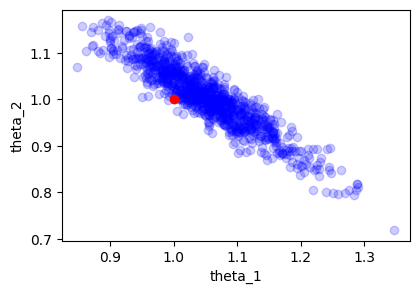

In [65]:
plot_theta_samples(theta_samples, theta_true, save_name=os.path.join(save_dirs.plots, "theta_samples_plot.pdf"))

Solution space posterior

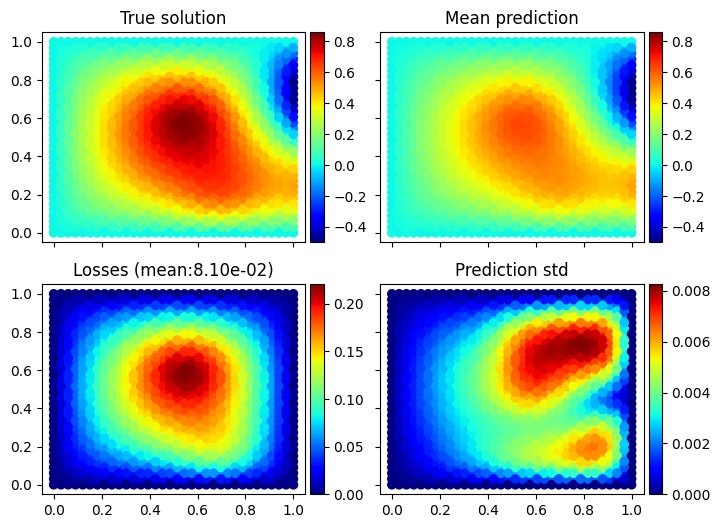

In [66]:
plot_us_posterior(test_data.Xs, test_data.us, us_samples, save_name=os.path.join(save_dirs.plots, f'posteriorPrediction.pdf'))

### Comparison with ground-truth solution data

In [67]:
gt_eval_results = ground_truth_evaluation(test_data.us, theta_true, us_samples, theta_samples)

Results evaluation against ground truth
u_rmse - mean/std     : 0.10184/0.00274
u_mpl  - mean/std     : 130799.88281/1885536.37500
theta_rmse - mean/std : 0.06899/0.04292
theta_entropy         : -2.41052


In [68]:
save_dict_to_txt(gt_eval_results, os.path.join(save_dirs.stats, f"ground_truth_evaluation.txt"))

### Comparison with gold standard MCMC results

In [70]:
assert (NOISE_FRAC == 0.1) and (train_data.Xu.shape[0]==25), f"MCMC results only available for NOISE_FRAC=0.1, Nu=50"

# directory where the MCMC samples are saved
gold_standard_dir = f"results/poisson2D/nutsFEM"

assert os.path.exists(gold_standard_dir)

gold_standard_samples = load_posterior_samples(gold_standard_dir)

# make sure the function space samples are the correct shape
if len(gold_standard_samples.us_samples.shape) == 3:
    gold_standard_samples.us_samples = gold_standard_samples.us_samples.squeeze()
    
gold_standard_samples.us_samples.shape, gold_standard_samples.theta_samples.shape 

((140, 1156), (700, 2))

In [71]:
gs_eval_results = gold_standard_evaluation(gold_standard_samples.us_samples, gold_standard_samples.theta_samples, us_samples, theta_samples)

Results evaluation against gold standard
u_nipg     : 94.68
theta_nipg : 99.58
theta_jsd  : 0.49


In [72]:
save_dict_to_txt(gs_eval_results, os.path.join(save_dirs.stats, f"gold_standard_evaluation.txt"))